Step 1: planning 

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

movies = pd.read_csv("../data/movies.csv")
ratings = pd.read_csv("../data/ratings.csv")

print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)

display(movies.head())
display(ratings.head())

Movies shape: (10329, 3)
Ratings shape: (105339, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,16,4.0,1217897793
1,1,24,1.5,1217895807
2,1,32,4.0,1217896246
3,1,47,4.0,1217896556
4,1,50,4.0,1217896523


In [31]:
print("\nMovies Information:")
movies.info()

print("\nRatings Information:")
ratings.info()


Movies Information:
<class 'pandas.DataFrame'>
RangeIndex: 10329 entries, 0 to 10328
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  10329 non-null  int64
 1   title    10329 non-null  str  
 2   genres   10329 non-null  str  
dtypes: int64(1), str(2)
memory usage: 656.0 KB

Ratings Information:
<class 'pandas.DataFrame'>
RangeIndex: 105339 entries, 0 to 105338
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     105339 non-null  int64  
 1   movieId    105339 non-null  int64  
 2   rating     105339 non-null  float64
 3   timestamp  105339 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.2 MB


In [32]:
print("Missing values in movies:")
print(movies.isnull().sum())

print("\nMissing values in ratings:")
print(ratings.isnull().sum())

Missing values in movies:
movieId    0
title      0
genres     0
dtype: int64

Missing values in ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


In [33]:
print("Duplicate movies:", movies.duplicated().sum())
print("Duplicate ratings:", ratings.duplicated().sum())

Duplicate movies: 0
Duplicate ratings: 0


Exploratory Data Analysis

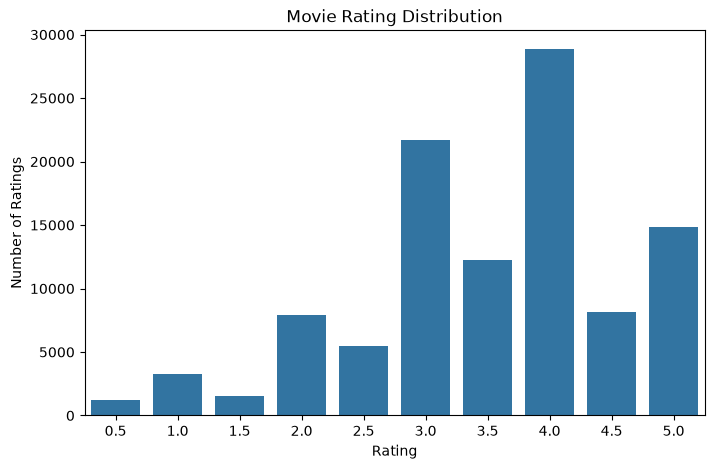

In [58]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x="rating",
    data=ratings
)

plt.title("Movie Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.show()

Most-rated movies

In [59]:
movie_rating_count = (
    ratings.groupby("movieId")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_movies = movie_rating_count.reset_index()

top_movies = top_movies.merge(
    movies,
    on="movieId"
)

print(top_movies[["title", 0]])

                                       title    0
0                        Pulp Fiction (1994)  325
1                        Forrest Gump (1994)  311
2           Shawshank Redemption, The (1994)  308
3                       Jurassic Park (1993)  294
4           Silence of the Lambs, The (1991)  290
5  Star Wars: Episode IV - A New Hope (1977)  273
6                         Matrix, The (1999)  261
7          Terminator 2: Judgment Day (1991)  253
8                    Schindler's List (1993)  248
9                          Braveheart (1995)  248


In [60]:
movie_statistics = ratings.groupby("movieId").agg(
    average_rating=("rating", "mean"),
    number_of_ratings=("rating", "count")
).reset_index()

movie_statistics = movie_statistics.merge(
    movies,
    on="movieId"
)

print(
    movie_statistics
    .sort_values("average_rating", ascending=False)
    .head(10)[
        ["title", "average_rating", "number_of_ratings"]
    ]
)

                                               title  average_rating  \
10296                                     Air (2015)             5.0   
10281             Everything's Gonna Be Great (1998)             5.0   
10279                            The Revenant (2015)             5.0   
412                            Heaven & Earth (1993)             5.0   
8878   Castaway on the Moon (Kimssi pyoryugi) (2009)             5.0   
8483                      Flesh and the Devil (1926)             5.0   
1854                           Hard Core Logo (1996)             5.0   
2866                               Possession (1981)             5.0   
2824                                Limelight (1952)             5.0   
2653                     Bride of the Monster (1955)             5.0   

       number_of_ratings  
10296                  1  
10281                  1  
10279                  1  
412                    1  
8878                   1  
8483                   1  
1854              